# MURI: Modelling actuator self-assembly

## Imports statements and setup

First, import statements

In [1]:
import numpy as np
import pyvista as pv
import polyscope as ps
import fabsim_py
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import IPython.display
import csv
import cv2
import igl

Initialize polyscope

In [2]:
ps.init()
ps.set_give_focus_on_show(True)
ps.set_ground_plane_mode("shadow_only")

ps.set_navigation_style("planar")
ps.set_view_projection_mode("orthographic")
ps.set_SSAA_factor(3)
ps.set_view_from_json('{"farClipRatio":20.0,"fov":16.0,"nearClipRatio":0.005,"projectionMode":"Orthographic","viewMat":[1.0,-0.0,0.0,-0.0,0.0,0.997785151004791,-0.0665190145373344,0.000246047973632812,-0.0,0.0665190145373344,0.997785151004791,-25.5602951049805,0.0,0.0,0.0,1.0],"windowHeight":1964,"windowWidth":3456}')

[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.1 Metal - 89.4


Constants

In [3]:
dt = 1 / 24
k0 = 1e-4
k1 = 5e-2
kd = 0.1 # rate of dissociation
e0 = 1.2e-1
e1 = 1.7e-1
frac_f = 0.7
frac_s = 0.25
n = 16
world_coords_to_px = 2878 / 2.275

Fix DOFs

In [4]:
fixed_dofs = []

def fix_dofs_in_circle(radius, center, V):
  for i in range(V.shape[0]):
    if np.linalg.norm(center - V[i, :2]) < radius + 1e-6:
      if center[0] * (center[0] - V[i, 0]) < 1:
        fixed_dofs.append(2 * i)
        fixed_dofs.append(2 * i + 1)

print(fixed_dofs)

[]


Display compaction with polar plots

In [5]:
def polygons_polar_plot(polymer_frac, scale):
  n = polymer_frac.shape[1]
  polygon = []
  rotated_polygon = []
  for i in range(n):
    angle = np.pi / n * i
    polygon.append(np.array([np.cos(angle), np.sin(angle), 0.0]))
    rotated_polygon.append(np.array([np.cos(angle + np.pi), np.sin(angle + np.pi), 0.0]))
  polygon = scale * np.array(polygon)
  rotated_polygon = scale * np.array(rotated_polygon)

  # faces = np.arange(F.shape[0] * 2 * n).reshape(F.shape[0], 2 * n)
  polygon_face = np.zeros((2 * n, 3))
  polygon_face[:, 1] = np.arange(1, 2 * n + 1)
  polygon_face[:, 2] = np.arange(2, 2 * n + 2)
  polygon_face[2 * n - 1, 2] = 1

  verts = []
  faces = []
  for i in range(F.shape[0]):
    center = (V[F[i, 0], :] + V[F[i, 1], :] + V[F[i, 2], :]) / 3
    verts.append(center.reshape((1, 3)))
    verts.append(polygon * polymer_frac[i, :][:, None] + center)
    verts.append(rotated_polygon * polymer_frac[i, :][:, None] + center)
    faces.append(polygon_face + i * (2 * n + 1))
  verts = np.concatenate(verts, axis=0)
  verts[:, 2] = 0.1
  faces = np.concatenate(faces, axis=0)

  return verts, faces

CSV data processing

In [6]:
def read_csv_to_array(filename):
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        data = [list(map(float, row)) for row in reader]
    return np.array(data)

def csv_to_image(data, output_file='output_image.png', base_cmap='viridis'):
    # Create a mask for zero values
    mask = (data == 0)

    # Use masked array to separate zeros from other values
    masked_data = np.ma.masked_where(mask, data)

    # Get base colormap and create a new colormap with black as the "bad" (masked) value
    cmap = plt.get_cmap(base_cmap)
    cmap.set_bad(color='black')
    
    plt.imshow(masked_data, cmap=cmap)
    plt.colorbar()  # Optional: shows color scale
    plt.axis('off')  # Hides axes
    plt.show()

Load initial mesh and display

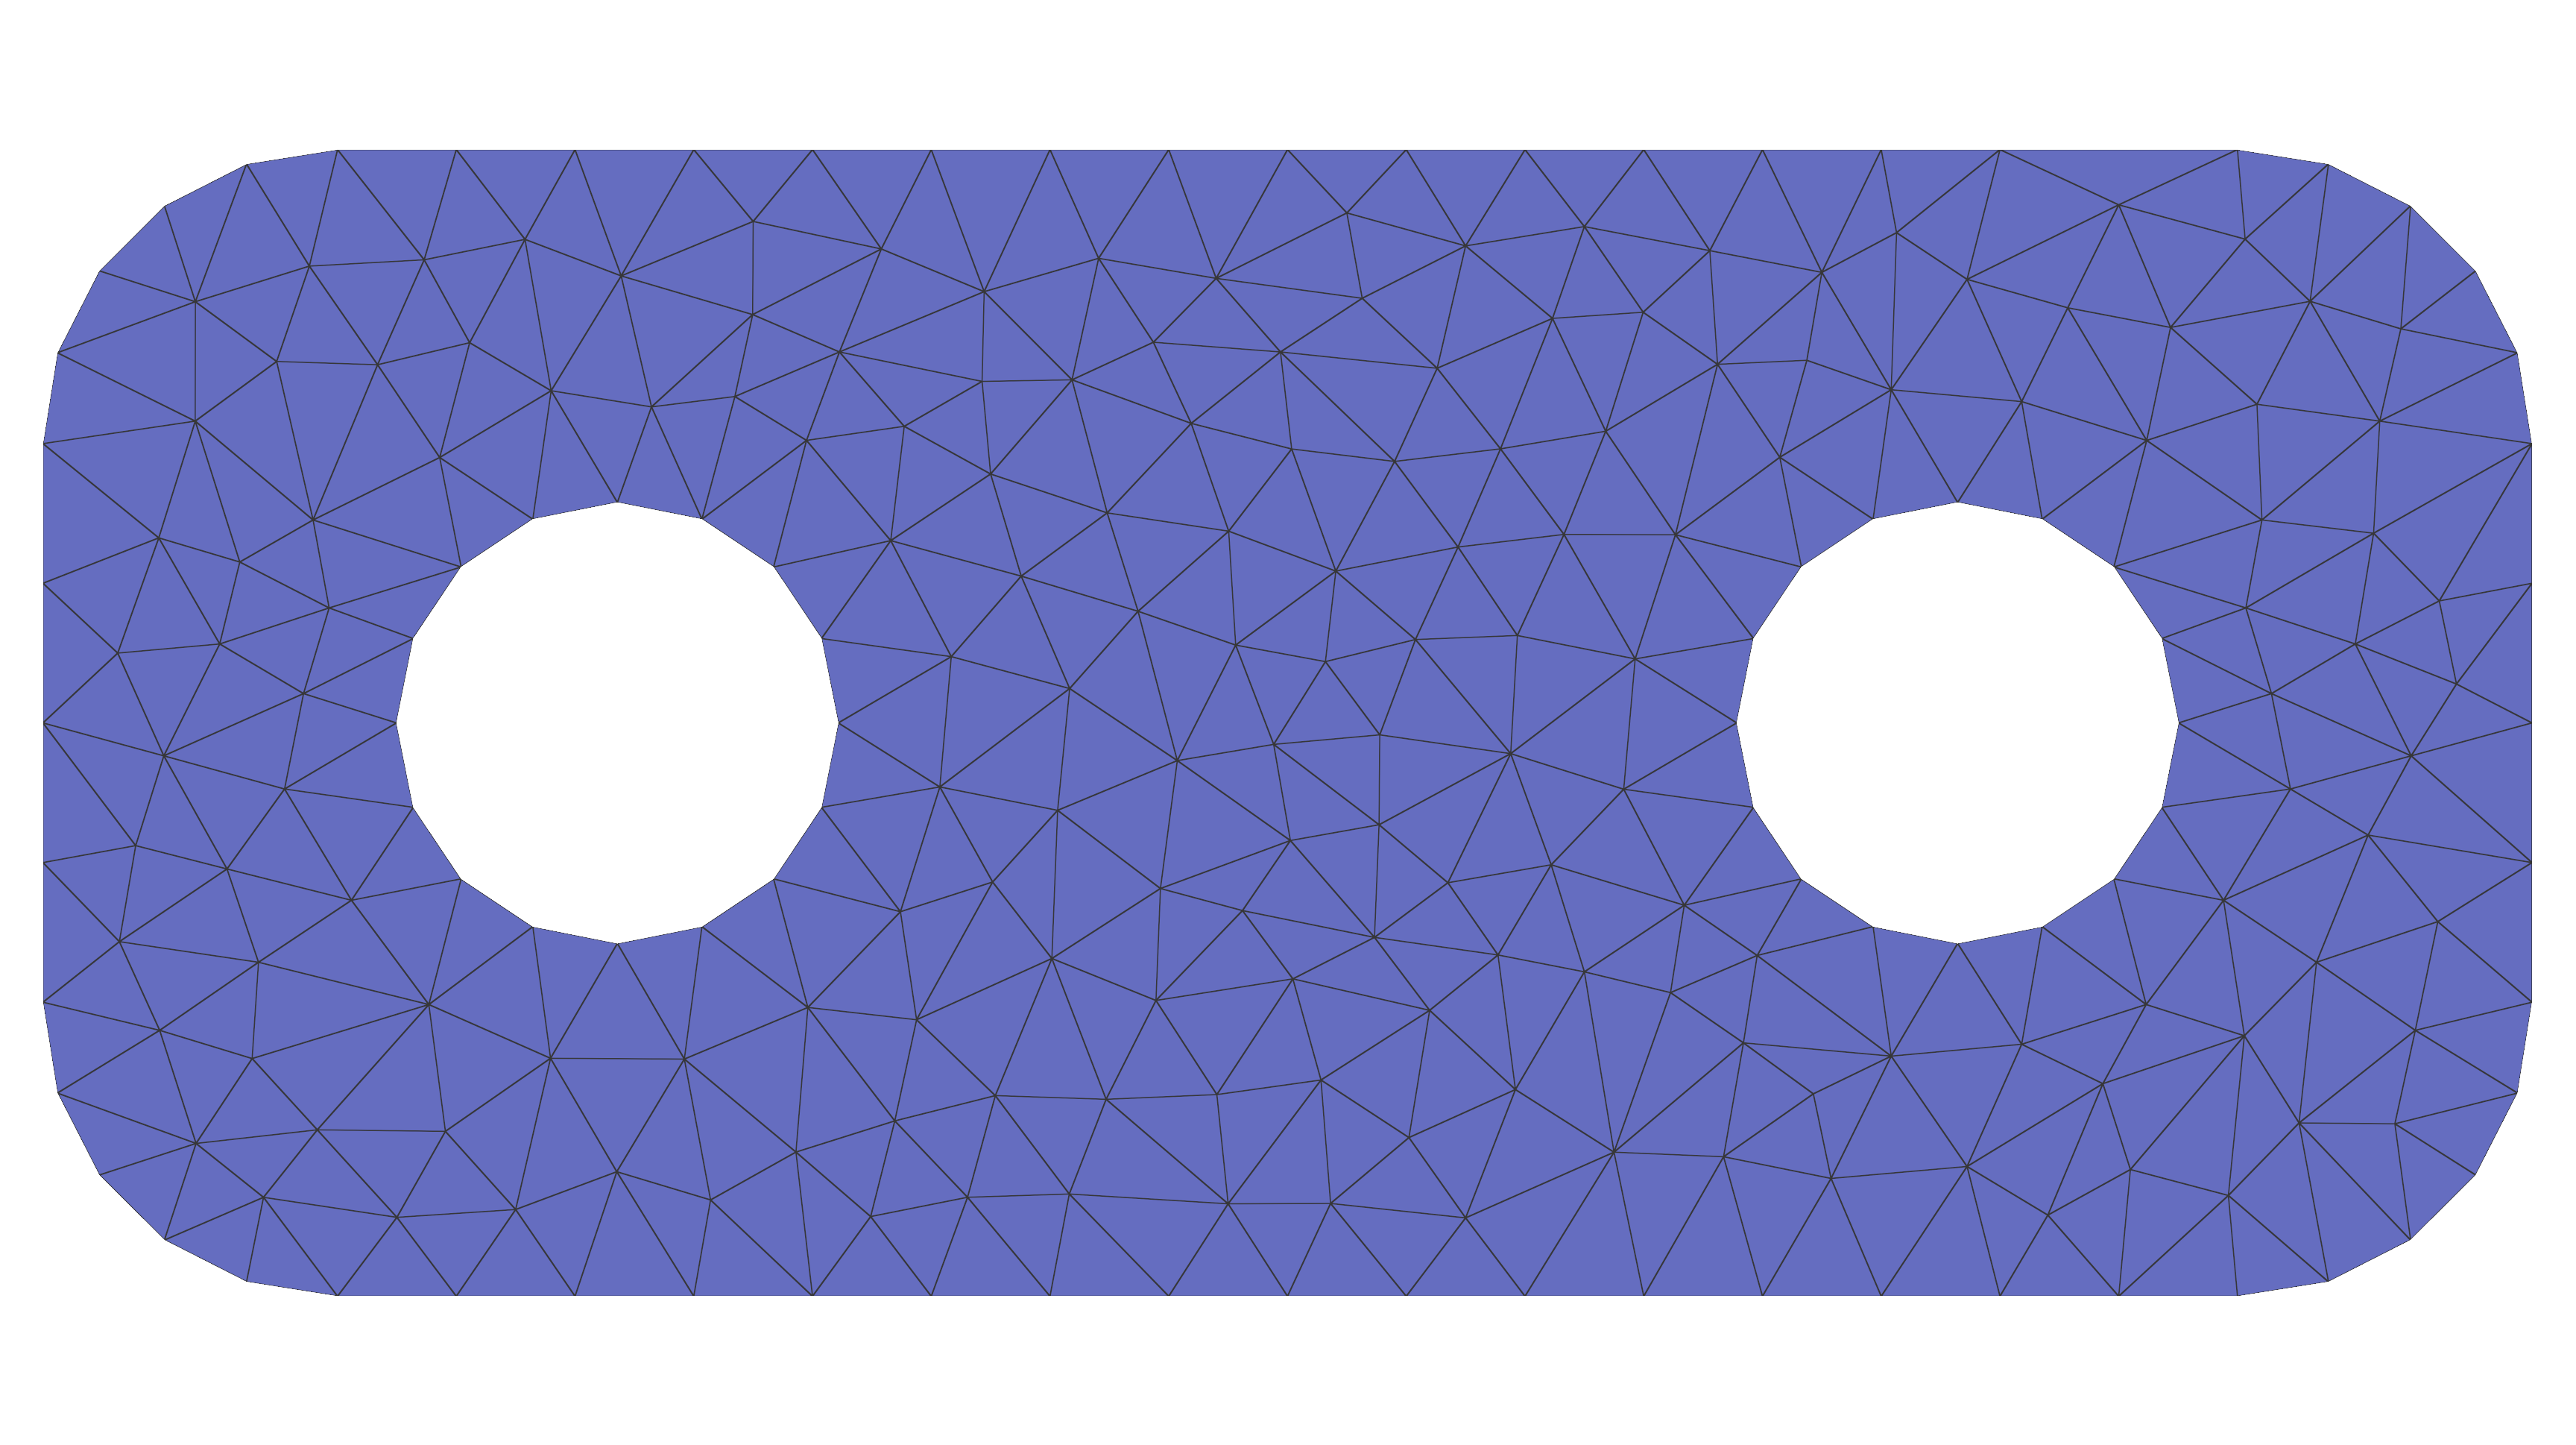

In [7]:
mesh = pv.read("data/top_surface.obj")
P = np.array(mesh.points, dtype=np.float64)
F = np.array(mesh.faces, dtype=np.int32)
F = F.reshape((F.shape[0] // 4, 4))[:, 1:]
P = P[:,:2]

ps_mesh = ps.register_surface_mesh("Initial mesh", P, F, smooth_shade=True, enabled=True, color=(42/255, 53/255, 213/255), edge_width=1)

fixed_dofs = []
X = np.reshape(P, 2 * P.shape[0])

fix_dofs_in_circle(0.75, np.array([-4.55/2, 0]), P)
X[fixed_dofs] += 2 * (4.55/2 - 2.2)
fix_dofs_in_circle(0.75, np.array([4.55/2, 0]), P)
X[fixed_dofs] -= (4.55/2 - 2.2)

P[:, 0] = np.reshape(X, P.shape)[:, 0]
fixed_dofs = np.sort(fixed_dofs)

ps.show()
ps.screenshot(filename='data/temp.png')
ps_mesh.set_enabled(False)
IPython.display.Image(filename='data/temp.png') 

## Steady-state solution for fiber distribution

In [8]:
stretch_factor = 1.1
polymer_frac = np.zeros((F.shape[0], n))
P = P[:,:2]
V = P.copy()

for j in range(15):
  print(stretch_factor)
  fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch_factor, 0.49)
  # for i in range(3):
    # stress = fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
    # polymer_frac = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)
  stretch_factor += 0.1

#   if j % 3 == 1:
#     V, P, F = fabsim_py.remesh(V, P, F, "pqa0.005")

#     fixed_dofs = []
#     fix_dofs_in_circle(0.75, np.array([-4.55/2, 0]), V)
#     fix_dofs_in_circle(0.75, np.array([4.55/2, 0]), P)
#     fix_z_dofs(V)
#     fixed_dofs = np.sort(fixed_dofs)
#     polymer_frac = np.zeros((F.shape[0], n))

# verts, faces = polygons_polar_plot(polymer_frac, 0.25)
# ps.register_surface_mesh("polymer frac", verts, faces, enabled=True, color=(213/255, 202/255, 42/255))
ps.register_surface_mesh("deformed", V, F, smooth_shade=True, color=(42/255, 53/255, 213/255), edge_width=1)

# ps.screenshot(filename='data/temp.png')
# IPython.display.Image(filename='data/temp.png') 
ps.show()

1.1
1.2000000000000002
1.3000000000000003
1.4000000000000004
1.5000000000000004
1.6000000000000005
1.7000000000000006
1.8000000000000007
1.9000000000000008
2.000000000000001
2.100000000000001
2.200000000000001
2.300000000000001
2.4000000000000012
2.5000000000000013


In [ ]:
X = np.reshape(P, 2 * P.shape[0])
X[fixed_dofs]

array([-1.98798743e+00,  6.92909649e-01, -2.27500000e+00,  7.50000000e-01,
       -2.56201257e+00,  6.92909649e-01, -2.80533009e+00,  5.30330086e-01,
       -2.96790965e+00,  2.87012574e-01, -3.02500000e+00,  9.18485099e-17,
       -2.96790965e+00, -2.87012574e-01, -2.80533009e+00, -5.30330086e-01,
       -2.56201257e+00, -6.92909649e-01, -2.27500000e+00, -7.50000000e-01,
       -1.98798743e+00, -6.92909649e-01,  3.02500000e+00,  0.00000000e+00,
        2.96790965e+00,  2.87012574e-01,  2.80533009e+00,  5.30330086e-01,
        2.56201257e+00,  6.92909649e-01,  2.27500000e+00,  7.50000000e-01,
        1.98798743e+00,  6.92909649e-01,  1.98798743e+00, -6.92909649e-01,
        2.27500000e+00, -7.50000000e-01,  2.56201257e+00, -6.92909649e-01,
        2.80533009e+00, -5.30330086e-01,  2.96790965e+00, -2.87012574e-01])

In [ ]:
Y = np.reshape(V, 2 * V.shape[0])
Y[fixed_dofs]

array([-1.98798743e+00,  6.92909649e-01, -2.27500000e+00,  7.50000000e-01,
       -2.56201257e+00,  6.92909649e-01, -2.80533009e+00,  5.30330086e-01,
       -2.96790965e+00,  2.87012574e-01, -3.02500000e+00,  9.18485099e-17,
       -2.96790965e+00, -2.87012574e-01, -2.80533009e+00, -5.30330086e-01,
       -2.56201257e+00, -6.92909649e-01, -2.27500000e+00, -7.50000000e-01,
       -1.98798743e+00, -6.92909649e-01,  3.02500000e+00,  0.00000000e+00,
        2.96790965e+00,  2.87012574e-01,  2.80533009e+00,  5.30330086e-01,
        2.56201257e+00,  6.92909649e-01,  2.27500000e+00,  7.50000000e-01,
        1.98798743e+00,  6.92909649e-01,  1.98798743e+00, -6.92909649e-01,
        2.27500000e+00, -7.50000000e-01,  2.56201257e+00, -6.92909649e-01,
        2.80533009e+00, -5.30330086e-01,  2.96790965e+00, -2.87012574e-01])

## Convergence of solutions

Convergence of ODE

In [ ]:
face_id = 392
stretch_factor = 1.5
polymer_frac = np.zeros((F.shape[0], n))
V = V.copy()
phi_t = [np.zeros(n)]

for i in range(1000):
  fabsim_py.simulate_membrane(V, V, F, polymer_frac, fixed_dofs, stretch_factor, 0.25)
  sigmas = 1.0 * fabsim_py.fiber_stress(V, V / stretch_factor, F, n)
  fabsim_py.polymer_fraction_one_step(polymer_frac, sigmas, k0, k1, kd, frac_f, frac_s, dt)
  phi_t.append(polymer_frac[face_id, :].copy())

phi_t = np.array(phi_t)

for i in range(n):
  plt.plot(phi_t[:, i])
plt.show()

Convergence of steady-state solution

In [ ]:
stretch_factor = 1.5
polymer_frac = np.zeros((F.shape[0], n))
V = P.copy()
phi_t = [np.zeros(n)]

for i in range(10):
  fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch_factor, 0.25, 1.0, e0, e1)
  stress = fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
  polymer_frac = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)
  phi_t.append(polymer_frac[face_id, :].copy())

phi_t = np.array(phi_t)

for i in range(n):
  plt.plot(phi_t[:, i])
plt.show()

## Nonlinear least-squares fitting for ODE coefficients

In [ ]:
def fitting(phi_measured):
  def fun(params):
    k1 = params[0]
    kd = params[1]
    e0 = params[2]
    e1 = params[3]

    stress = fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
    phi = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)

    for i in range(2):
      fabsim_py.simulate_membrane(V, P, F, phi, fixed_dofs, stretch_factor, 0.25)
      stress = fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
      phi = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)

    return (phi - phi_measured).flatten()

  initial_guess = np.array([5e-2, 0.1, 1.2e-1, 1.7e-1])
  return least_squares(fun, initial_guess, verbose=2)

Polar plot for "ground truth" solution

In [ ]:
stretch_factor = 1.5
n = 32
polymer_frac = np.zeros((F.shape[0], n))
V = P.copy()

for i in range(3):
  fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch_factor, 0.25)
  stress = fabsim_py.fiber_stress(V, P / stretch_factor, F, n, e0, e1)
  polymer_frac = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)

_, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot([np.pi / n * i for i in range(3 * n)], np.tile(polymer_frac[face_id, :], 3))
ax.set_rmax(0.12)

plt.show()

Polar plot for fake "measured data" (= ground thruth + noise)

In [ ]:
phi_measured = polymer_frac + 0.01 * np.random.default_rng().random(polymer_frac.shape)

_, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot([np.pi / n * i for i in range(3 * n)], np.tile(phi_measured[face_id, :], 3))
ax.set_rmax(0.12)

plt.show()

In [ ]:
params = fitting(phi_measured)

print(k1, kd, e0, e1)

k1 = params.x[0]
kd = params.x[1]
e0 = params.x[2]
e1 = params.x[3]

print(k1, kd, e0, e1)

phi_recovered = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)

_, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot([np.pi / n * i for i in range(3 * n)], np.tile(phi_recovered[face_id, :], 3))
ax.set_rmax(0.12)

plt.show()

## Get orientation and intensity data

Load orientation CSV data

In [ ]:
input_csv = 'data/Orientation_angles_72hrs_compact_S1_16x_16x4_tilescan.csv'  # Replace with your filename
orientation_array = read_csv_to_array(input_csv)
orientation_array = orientation_array.T[50:,50:]
# csv_to_image(orientation_array, base_cmap='hsv')
cv2.imwrite('data/temp.png', orientation_array * 255 / np.pi)
IPython.display.Image(filename='data/temp.png')

In [ ]:
input_csv = 'data/orientation_angles_S2_72hrs_compact_16x_16x5_tilescan_denoise.csv'  # Replace with your filename
orientation_array = read_csv_to_array(input_csv)
orientation_array = orientation_array.T
# csv_to_image(orientation_array, base_cmap='hsv')
cv2.imwrite('data/temp.png', orientation_array * 255 / np.pi)
IPython.display.Image(filename='data/temp.png')

In [ ]:
input_csv = 'data/orientation_angles_S3_72hrs_compact_16x_16x5_tilescan_denoise.csv'  # Replace with your filename
orientation_array = read_csv_to_array(input_csv)
orientation_array = orientation_array.T
# csv_to_image(orientation_array, base_cmap='hsv')
cv2.imwrite('data/temp.png', orientation_array * 255 / np.pi)
IPython.display.Image(filename='data/temp.png')

Load pixel intensity CSV data

In [ ]:
input_csv = 'data/pixel_intensity_72hrs_compact_S1_16x_16x4_tilescan.csv'  # Replace with your filename
intensity_array = read_csv_to_array(input_csv)
intensity_array = intensity_array[50:,50:]

cv2.imwrite('data/temp.png', intensity_array * 255 / np.max(intensity_array))
IPython.display.Image(filename='data/temp.png')

In [ ]:
input_csv = 'data/pixel_intensity_S2_72hrs_compact_16x_16x5_tilescan_denoise.csv'  # Replace with your filename
intensity_array2 = read_csv_to_array(input_csv)
intensity_array2 = intensity_array2.T

cv2.imwrite('data/temp.png', intensity_array2 * 255 / np.max(intensity_array2))
IPython.display.Image(filename='data/temp.png')

In [ ]:
input_csv = 'data/pixel_intensity_S3_72hrs_compact_16x_16x5_tilescan_denoise.csv'  # Replace with your filename
intensity_array3 = read_csv_to_array(input_csv)
intensity_array3 = intensity_array3.T

cv2.imwrite('data/temp.png', intensity_array3 * 255 / np.max(intensity_array3))
IPython.display.Image(filename='data/temp.png')

## Simulation comparisons

In [ ]:
def vertex_polar_plot(polymer_frac, scale):
  n = polymer_frac.shape[1]
  polygon = []
  rotated_polygon = []
  for i in range(n):
    angle = np.pi / n * i
    polygon.append(np.array([np.cos(angle), np.sin(angle), 0.0]))
    rotated_polygon.append(np.array([np.cos(angle + np.pi), np.sin(angle + np.pi), 0.0]))
  polygon = scale * np.array(polygon)
  rotated_polygon = scale * np.array(rotated_polygon)

  # faces = np.arange(F.shape[0] * 2 * n).reshape(F.shape[0], 2 * n)
  polygon_face = np.zeros((2 * n, 3))
  polygon_face[:, 1] = np.arange(1, 2 * n + 1)
  polygon_face[:, 2] = np.arange(2, 2 * n + 2)
  polygon_face[2 * n - 1, 2] = 1

  verts = []
  faces = []
  for i in range(V.shape[0]):
    verts.append(V[i, :].reshape((1, 3)))
    verts.append(polygon * polymer_frac[i, :][:, None] + V[i, :])
    verts.append(rotated_polygon * polymer_frac[i, :][:, None] + V[i, :])
    faces.append(polygon_face + i * (2 * n + 1))
  verts = np.concatenate(verts, axis=0)
  verts[:, 2] = 0.1
  faces = np.concatenate(faces, axis=0)

  return verts, faces

Shape from simulated fibers

In [ ]:
# Phi = fabsim_py.histogram_data_to_mesh(V, F, orientation_array, world_coords_to_px, 0.3, n)
Phi = fabsim_py.histogram_data_to_mesh(V, F, orientation_array, world_coords_to_px, 0.6, n)

# normalize Phi
Phi = Phi / np.fmax(np.sum(Phi, axis=1, keepdims=True), 1) * 0.05 * 16

verts, faces = vertex_polar_plot(Phi, 0.25)
ps.register_surface_mesh("polymer frac", verts, faces, enabled=True, color=(213/255, 202/255, 42/255))
ps_mesh = ps.register_surface_mesh("deformed", V, F, smooth_shade=True, color=(42/255, 53/255, 213/255), edge_width=1)

# ps.show()
ps.screenshot(filename='data/temp.png')
IPython.display.Image(filename='data/temp.png') 

Shape from measured fibers

In [ ]:
# get orientation
Phi = fabsim_py.histogram_data_to_mesh(V, F, orientation_array, world_coords_to_px, 0.6, n)
Phi = Phi / np.fmax(np.sum(Phi, axis=1, keepdims=True), 1) * 0.05 * 16

# sim
stretch_factor = 2.5
Phi_sim = (Phi[F[:, 0]] + Phi[F[:, 1]] + Phi[F[:, 2]]) / 3
print(np.sum(Phi_sim))

fabsim_py.simulate_membrane(V, P, F, Phi_sim, fixed_dofs, stretch_factor, 0.49)

# display
verts, faces = vertex_polar_plot(Phi, 0.25)
ps.register_surface_mesh("polymer frac", verts, faces, enabled=True, color=(213/255, 202/255, 42/255))
ps_mesh = ps.register_surface_mesh("deformed", V, F, smooth_shade=True, color=(42/255, 53/255, 213/255), edge_width=1)
ps.screenshot(filename='data/temp.png')
IPython.display.Image(filename='data/temp.png') 
# ps.show()

Shape from measured fibers with intensity scaling

In [ ]:
# get intensity and orientation
intensity = fabsim_py.image_data_to_mesh(V, F, intensity_array, world_coords_to_px)
Phi = fabsim_py.histogram_data_to_mesh(V, F, orientation_array, world_coords_to_px, 0.6, n)

# rescale intensity
intensity = intensity / np.max(intensity)

# rescale Phi
Phi = Phi / np.fmax(np.sum(Phi, axis=1, keepdims=True), 1) * 0.05 * 16
Phi = Phi * intensity

# sim
stretch_factor = 2.5
Phi_sim = (Phi[F[:, 0]] + Phi[F[:, 1]] + Phi[F[:, 2]]) / 3

fabsim_py.simulate_membrane(V, P, F, Phi_sim, fixed_dofs, stretch_factor, 0.49)

# display
verts, faces = vertex_polar_plot(Phi, 0.25)
ps.register_surface_mesh("polymer frac", verts, faces, enabled=True, color=(213/255, 202/255, 42/255))
ps_mesh = ps.register_surface_mesh("deformed", V, F, smooth_shade=True, color=(42/255, 53/255, 213/255), edge_width=1)
ps.screenshot(filename='data/temp.png')
IPython.display.Image(filename='data/temp.png') 
# ps.show()

## Fitting

In [ ]:
# get orientation
Phi = fabsim_py.histogram_data_to_mesh(V, F, orientation_array, world_coords_to_px, 0.6, n)
Phi = Phi / np.fmax(np.sum(Phi, axis=1, keepdims=True), 1) * 0.05 * 16

# sim
stretch_factor = 2.5
phi_measured = (Phi[F[:, 0]] + Phi[F[:, 1]] + Phi[F[:, 2]]) / 3

fabsim_py.simulate_membrane(V, P, F, phi_measured, fixed_dofs, stretch_factor, 0.49)

params = fitting(phi_measured)

print(k1, kd, e0, e1)

k1 = params.x[0]
kd = params.x[1]
e0 = params.x[2]
e1 = params.x[3]

print(k1, kd, e0, e1)

phi_recovered = fabsim_py.polymer_fraction_steady_state(stress, 1, k1 / k0, kd / k0, frac_f, frac_s)

fabsim_py.simulate_membrane(V, P, F, phi_recovered, fixed_dofs, stretch_factor, 0.49)

# display
verts, faces = polygons_polar_plot(phi_measured, 0.25)
ps.register_surface_mesh("phi_measured", verts, faces, enabled=False, color=(213/255, 202/255, 42/255))
verts, faces = polygons_polar_plot(phi_recovered, 0.25)
ps.register_surface_mesh("phi_recovered", verts, faces, enabled=True, color=(213/255, 202/255, 42/255))
ps_mesh = ps.register_surface_mesh("deformed", V, F, smooth_shade=True, color=(42/255, 53/255, 213/255), edge_width=1)
ps.screenshot(filename='data/temp.png')
IPython.display.Image(filename='data/temp.png') 
# ps.show()

## Tissue mesh extraction

Generate intensity mask

In [ ]:
mask = np.array(intensity_array > 300, dtype=float)

# Define a structuring element (kernel)
kernel = np.ones((25,25), np.uint8)

# Apply dilation
dilated_mask = cv2.dilate(mask, kernel, iterations=1)


cv2.imwrite('data/temp.png', dilated_mask * 255 / np.max(dilated_mask))
IPython.display.Image(filename='data/temp.png')

In [ ]:
mask = np.array(intensity_array2 > 300, dtype=float)

# Define a structuring element (kernel)
kernel = np.ones((25,25), np.uint8)

# Apply dilation
dilated_mask2 = cv2.dilate(mask, kernel, iterations=1)


cv2.imwrite('data/temp.png', dilated_mask2 * 255 / np.max(dilated_mask2))
IPython.display.Image(filename='data/temp.png')

In [ ]:
mask = np.array(intensity_array3 > 150, dtype=float)

# Define a structuring element (kernel)
kernel = np.ones((25,25), np.uint8)

# Apply dilation
dilated_mask3 = cv2.dilate(mask, kernel, iterations=1)

cv2.imwrite('data/temp.png', dilated_mask3 * 255 / np.max(dilated_mask3))
IPython.display.Image(filename='data/temp.png')

# Generate SDF from tissue outline

In [8]:
from scipy.ndimage import distance_transform_edt

def generate_distance_from_mask(mask, show=False):
    mask = np.array(mask, dtype=bool)
    # Compute distance to the background (outside object)
    dist_outside= distance_transform_edt(mask, return_indices=False)

    # Compute distance to the foreground (inside object)
    dist_inside = distance_transform_edt(~mask, return_indices=False)

    # Signed Distance Field: negative inside, positive outside
    dist = 0.5 * (dist_outside - dist_inside)**2

    if show:
        plt.imshow(0.7769e-3 * (dist_inside - dist_outside), cmap='cividis')
        plt.colorbar(label='Signed Distance (mm)')
        plt.axis('off')
        plt.show()
    return dist

In [9]:
n_cols = int(np.ceil(1287.2 * 4.225)) + 10
n_rows = int(np.ceil(1287.2 * 1.95)) + 10

dist = np.empty((n_rows, n_cols))
grad = np.empty((2, n_rows, n_cols))

for i in range(1,4):
  mask = cv2.imread(f"data/mask{i}.png", cv2.IMREAD_GRAYSCALE) > 128
  height, width = mask.shape
  
  mask1 = np.full((n_rows, n_cols), False)
  mask1[n_rows - height//2:n_rows, 0:width//2] += np.flip(mask[0:height//2, 0:width//2], axis=1)
  dist1 = generate_distance_from_mask(mask1, show=False)

  mask2 = np.full((n_rows, n_cols), False)
  mask2[n_rows - height//2:n_rows, 0:width//2] += np.flip(mask[height//2:height, 0:width//2], axis=(0, 1))
  dist2 = generate_distance_from_mask(mask2, show=False)

  mask3 = np.full((n_rows, n_cols), False)
  mask3[n_rows - height//2:n_rows, 0:width//2] += mask[0:height//2, width//2:width]
  dist3 = generate_distance_from_mask(mask3, show=False)

  mask4 = np.full((n_rows, n_cols), False)
  mask4[n_rows - height//2:n_rows, 0:width//2] += np.flip(mask[height//2:height, width//2:width], axis=0)
  dist4 = generate_distance_from_mask(mask4, show=False)

  dist += (dist1 + dist2 + dist3 + dist4) / 12

# cv2.imwrite('data/temp.png', dist * 255 / np.max(dist))
# IPython.display.Image(filename='data/temp.png')

In [10]:
ps.remove_all_structures()
P = P[:,:2]
polymer_frac = np.zeros((F.shape[0], n))
V = P.copy()

distance_grad_x = cv2.Sobel(dist, cv2.CV_64F, 1, 0, ksize=3)  # Gradient in X
distance_grad_y = cv2.Sobel(dist, cv2.CV_64F, 0, 1, ksize=3)  # Gradient in Y
residual_grad_x = cv2.Sobel(np.sqrt(2 * dist), cv2.CV_64F, 1, 0, ksize=3)  # Gradient in X
residual_grad_y = cv2.Sobel(np.sqrt(2 * dist), cv2.CV_64F, 0, 1, ksize=3)  # Gradient in Y

boundary_indices = igl.boundary_loop(F)

stretch = 1
d = fabsim_py.distance(V, boundary_indices, dist)
print(f"distance: {d}, stretch: {stretch}")

for i in range(50):
  fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch, 0.49)
  distance_grad = fabsim_py.distance_gradient(V, boundary_indices, distance_grad_x, distance_grad_y)
  residual_grad = fabsim_py.distance_gradient(V, boundary_indices, residual_grad_x, residual_grad_y)

  S = fabsim_py.sensitivity_matrix(V, F, fixed_dofs, stretch, 0.49)
  # S = V.copy()
  # fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch + 1e-4, 0.49)
  # S = np.reshape((S - V) / 1e-4, 2 * P.shape[0])

  ds = -distance_grad.dot(S) / (residual_grad.dot(S))**2
  stretch += 0.1

  d = fabsim_py.distance(V, boundary_indices, dist)

  # fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, stretch + ds, 0.49)
  # new_d = fabsim_py.distance(V, boundary_indices, dist)

  print(f"distance: {d}, stretch: {stretch}, gradient: {distance_grad.dot(S)}, ds: {ds}")

# mesh = ps.register_surface_mesh("deformed", V, F, smooth_shade=True, color=(42/255, 53/255, 213/255), edge_width=1)
# ps.show()


distance: 73898208.8885143, stretch: 1
NEWTON METHOD
Iter         Fval    Step size   Optimality
distance: 73898208.8885143, stretch: 1.1, gradient: -494745.2757679125, ds: 4.927587117330617
NEWTON METHOD
Iter         Fval    Step size   Optimality
   1    8.548e-02    1.000e+00    9.089e-02
   2    7.745e-02    1.000e+00    1.805e-03
   3    7.744e-02    1.000e+00    1.716e-06
   4    7.744e-02    1.000e+00    7.567e-13
distance: 52583944.5710003, stretch: 1.2000000000000002, gradient: -336770.1081929454, ds: 5.133292882175372
NEWTON METHOD
Iter         Fval    Step size   Optimality
   1    3.053e-01    1.000e+00    8.647e-02
   2    2.994e-01    1.000e+00    1.586e-03
   3    2.994e-01    1.000e+00    1.128e-06
   4    2.994e-01    1.000e+00    3.738e-13
distance: 37940317.36899116, stretch: 1.3000000000000003, gradient: -236179.770575538, ds: 5.258064002340319
NEWTON METHOD
Iter         Fval    Step size   Optimality
   1    6.580e-01    1.000e+00    8.281e-02
   2    6.536e-01    

213142643.17513993

In [8]:
ps.remove_all_structures()
P = P[:,:2]
polymer_frac = np.zeros((F.shape[0], n))
V = P.copy()

mesh = ps.register_surface_mesh("initial", P, F, smooth_shade=True, color=(42/255, 53/255, 213/255), edge_width=1)

stretch = 1
S = fabsim_py.sensitivity_matrix(V, F, fixed_dofs, stretch, 0.49)


fabsim_py.simulate_membrane(V, P, F, polymer_frac, fixed_dofs, 1.00001, 0.49)
mesh.add_vector_quantity("finite diff", (V - P) / 0.00001)
mesh.add_vector_quantity("sensitivity matrix", np.reshape(S, P.shape))

mesh = ps.register_surface_mesh("deformed", V, F, smooth_shade=True, color=(42/255, 53/255, 213/255), edge_width=1)

ps.show()

NEWTON METHOD
Iter         Fval    Step size   Optimality
   1    8.039e-10    1.000e+00    7.911e-10


In [ ]:
ps.remove_all_structures()
mesh = ps.register_surface_mesh("deformed", P, F, smooth_shade=True, color=(42/255, 53/255, 213/255), edge_width=1)
indices = list(range(P.shape[0]))

# Compute gradients using Sobel operator
grad_x = cv2.Sobel(dist, cv2.CV_64F, 1, 0, ksize=3)  # Gradient in X
grad_y = cv2.Sobel(dist, cv2.CV_64F, 0, 1, ksize=3)  # Gradient in Y
distance_grad = fabsim_py.distance_gradient(P, indices, grad_x, grad_y)
distance_grad = np.reshape(distance_grad, (P.shape[0], 2))

# distance = fabsim_py.distance_gradient(V, indices, dist, 0 * dist)
# distance = np.reshape(distance, (V.shape[0], 2))[:, 0]

mesh.add_vector_quantity("distance gradient", distance_grad)
# mesh.add_scalar_quantity("distance", np.abs(distance))
ps.show()


2521 5438
2521 5438
2521 1962
2521 3893
2521 3893
2521 1962


### Debug

In [ ]:
face_id = 1161
_, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot([np.pi / n * i for i in range(3 * n)], np.tile(polymer_frac[face_id, :], 3))
# ax.set_rmax(30)
plt.show()

In [ ]:
verts = np.array([[-0.5, -0.3], [0.5, 0.3]])
nY, nX = orientation_array.shape

(minX, maxY) = np.round(np.min(verts, axis=0)[:2] * np.array([1, -1]) * world_coords_to_px + np.array([nX, nY]) / 2).astype(int)
(maxX, minY) = np.round(np.max(verts, axis=0)[:2] * np.array([1, -1]) * world_coords_to_px + np.array([nX, nY]) / 2).astype(int)

sub_array = orientation_array[minY:maxY, minX:maxX]
values, angles = np.histogram(np.extract(sub_array != 0, sub_array), bins = n)
values = values / np.max(values)
values = values / np.sum(values)
_, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot([np.pi / 2 + np.pi / n * i for i in range(3 * n)], np.tile(values, 3))

# plt.hist(bins[:-1], bins, weights=counts)
plt.show()

In [ ]:
values = np.zeros(V.shape[0])

sigma = 0.3

# lower normal part of gaussian
normal = 1 / np.sqrt(2 * np.pi * sigma**2)

for i in range(V.shape[0]):
    # Calculating Gaussian filter
    values[i] = np.exp(-((np.linalg.norm(V[i, :]) / 0.6)**2 / (2.0 * sigma**2))) * normal

ps_mesh = ps.register_surface_mesh("deformed", V, F, smooth_shade=True, color=(42/255, 53/255, 213/255), edge_width=1)
ps_mesh.add_scalar_quantity("gaussian", values, defined_on='vertices', enabled=True)
ps.show()